In [1]:
from diffusers import UNet2DModel, DDIMScheduler, VQModel
import torch
import matplotlib.pyplot as plt
import numpy as np
import tqdm

seed = 7

/Users/clementgilli/.pyenv/versions/representation_learning/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/clementgilli/.pyenv/versions/representation_learning/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/clementgilli/.pyenv/versions/representation_learning/lib/python3.12/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [2]:
# run only once
download_models = False
if download_models:
    vqvae = VQModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="vqvae")
    unet = UNet2DModel.from_pretrained("CompVis/ldm-celebahq-256", subfolder="unet")
    scheduler = DDIMScheduler.from_pretrained("CompVis/ldm-celebahq-256", subfolder="scheduler")
    vqvae.save_pretrained("./models/vqvae")
    unet.save_pretrained("./models/unet")
    scheduler.save_pretrained("./models/scheduler")

In [3]:
vqvae = VQModel.from_pretrained("./models/vqvae")
unet = UNet2DModel.from_pretrained("./models/unet")
scheduler = DDIMScheduler.from_config("./models/scheduler")

torch_device = "cuda" if torch.cuda.is_available() else "cpu"

unet.to(torch_device)
vqvae.to(torch_device);

/Users/clementgilli/.pyenv/versions/representation_learning/lib/python3.12/site-packages/diffusers/configuration_utils.py:250: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.If you were trying to load a scheduler, please use <class 'diffusers.schedulers.scheduling_ddim.DDIMScheduler'>.from_pretrained(...) instead. Otherwise, please make sure to pass a configuration dictionary instead. This functionality will be removed in v1.0.0.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)
The config attributes {'timestep_values': None, 'timesteps': 1000} were passed to DDIMScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


In [4]:
generator = torch.manual_seed(seed)
noise = torch.randn(
    (1, unet.in_channels, unet.sample_size, unet.sample_size),
    generator=generator,
).to(torch_device)

/var/folders/9b/qtm3hv997z955rzj7w49g0580000gn/T/ipykernel_34123/2405944415.py:3: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DModel's config object instead, e.g. 'unet.config.in_channels'.
  (1, unet.in_channels, unet.sample_size, unet.sample_size),


In [5]:
# set inference steps for DDIM
scheduler.set_timesteps(num_inference_steps=20)
image = noise
for t in tqdm.tqdm(scheduler.timesteps):
    # predict noise residual of previous image
    with torch.no_grad():
        residual = unet(image, t)["sample"]

    # compute previous image x_t according to DDIM formula
    prev_image = scheduler.step(residual, t, image, eta=0.0)["prev_sample"]

    # x_t-1 -> x_t
    image = prev_image

# decode image with vae
with torch.no_grad():
    image = vqvae.decode(image)[0]

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:06<00:00,  3.26it/s]


In [6]:
image_processed = image.cpu().permute(0, 2, 3, 1)
image_processed = (image_processed + 1.0) * 127.5
image_processed = image_processed.clamp(0, 255).numpy().astype(np.uint8)


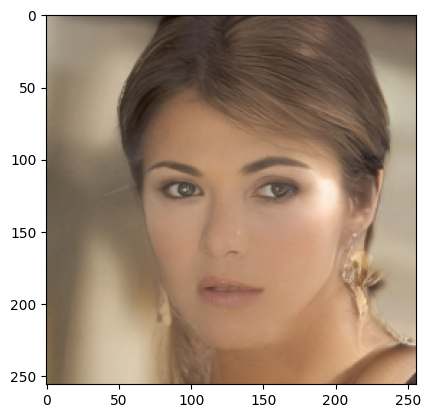

In [7]:
plt.imshow(image_processed.squeeze())